<a href="https://colab.research.google.com/github/ranjiparker/vst-animated/blob/main/yoloimproved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/ultralytics/yolov5.git

Cloning into 'yolov5'...
remote: Enumerating objects: 10008, done.
remote: Total 10008 (delta 0), reused 0 (delta 0), pack-reused 10008
Receiving objects: 100% (10008/10008), 10.31 MiB | 12.00 MiB/s, done.
Resolving deltas: 100% (6945/6945), done.


In [ ]:
!unzip /content/Animation-Faster-R-CNN.v3-yolo_mindseye.yolov5pytorch.zip

Archive:  /content/Animation-Faster-R-CNN.v3-yolo_mindseye.yolov5pytorch.zip
 extracting: README.dataset.txt      
 extracting: README.roboflow.txt     
 extracting: data.yaml               
   creating: test/
   creating: test/images/
 extracting: test/images/abstract_v002_train2015_000000000018_png.rf.93439e03c5fd2adc96ec70d203b6eb6b.jpg  
 extracting: test/images/abstract_v002_train2015_000000000034_png.rf.9ec05f355a2c4b5649c0ef1e5bd5da0d.jpg  
 extracting: test/images/abstract_v002_train2015_000000000044_png.rf.b6ad7169bb257f5eb47d6e076524c6cd.jpg  
 extracting: test/images/abstract_v002_train2015_000000000047_png.rf.2557fdd106090220e356858a74da35f2.jpg  
 extracting: test/images/abstract_v002_train2015_000000000049_png.rf.f983199325fd0772d5e8dce166a3432b.jpg  
 extracting: test/images/abstract_v002_train2015_000000000056_png.rf.ccf73ba0d70d58f7efabd65c795453d3.jpg  
 extracting: test/images/abstract_v002_train2015_000000000059_png.rf.ae507427740c1bf772405df248c72d71.jpg  
 extract

In [ ]:
%cd yolov5/

/content/yolov5


In [ ]:
!pip install -r requirements.txt

     |████████████████████████████████| 596 kB 4.3 MB/s 
  Attempting uninstall: PyYAML
    Found existing installation: PyYAML 3.13
    Uninstalling PyYAML-3.13:
      Successfully uninstalled PyYAML-3.13


In [ ]:
!python train.py --img 416 --batch 8 --epochs 103 --data /content/yolov5/data/coco128.yaml --weights yolov5s.pt --nosave --cache 

train: weights=yolov5s.pt, cfg=, data=/content/yolov5/data/coco128.yaml, hyp=data/hyps/hyp.scratch.yaml, epochs=103, batch_size=8, imgsz=416, rect=False, resume=False, nosave=True, noval=False, noautoanchor=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, adam=False, sync_bn=False, workers=8, project=runs/train, name=exp, exist_ok=False, quad=False, linear_lr=False, label_smoothing=0.0, patience=100, freeze=0, save_period=-1, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v6.0-103-g7a39803 torch 1.10.0+cu111 CUDA:0 (Tesla K80, 11441MiB)

hyperparameters: lr0=0.01, lrf=0.1, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, iou_t=0.2, anchor_t=4.0, fl_gamma=0.0, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, degrees=0.0, translate=

In [ ]:
!python val.py --weights runs/train/exp/weights/last.pt --data /content/yolov5/data/coco128.yaml --img 416 

val: data=/content/yolov5/data/coco128.yaml, weights=['runs/train/exp/weights/last.pt'], batch_size=32, imgsz=416, conf_thres=0.001, iou_thres=0.6, task=val, device=, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v6.0-103-g7a39803 torch 1.10.0+cu111 CUDA:0 (Tesla K80, 11441MiB)

Fusing layers... 
Model Summary: 213 layers, 7158460 parameters, 0 gradients, 16.3 GFLOPs
val: Scanning '/content/valid/labels.cache' images and labels... 31 found, 0 missing, 0 empty, 0 corrupted: 100% 31/31 [00:00<?, ?it/s]
               Class     Images     Labels          P          R     mAP@.5 mAP@.5:.95: 100% 1/1 [00:01<00:00,  1.50s/it]
                 all         31        172      0.637      0.411       0.41      0.223
Speed: 0.4ms pre-process, 11.6ms inference, 2.5ms NMS per image at shape (32, 3, 416, 416)
Results saved to runs/val/exp


In [ ]:
%cd /content/yolov5/
!python detect.py --weights runs/train/exp/weights/last.pt --img 416 --conf 0.4 --source /content/test/images --save-txt

/content/yolov5
detect: weights=['runs/train/exp/weights/last.pt'], source=/content/test/images, imgsz=[416, 416], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
YOLOv5 🚀 v6.0-103-g7a39803 torch 1.10.0+cu111 CUDA:0 (Tesla K80, 11441MiB)

Fusing layers... 
Model Summary: 213 layers, 7158460 parameters, 0 gradients, 16.3 GFLOPs
image 1/12 /content/test/images/abstract_v002_train2015_000000000018_png.rf.93439e03c5fd2adc96ec70d203b6eb6b.jpg: 416x416 1 man, 1 picture, 2 plants, 2 windows, Done. (0.029s)
image 2/12 /content/test/images/abstract_v002_train2015_000000000034_png.rf.9ec05f355a2c4b5649c0ef1e5bd5da0d.jpg: 416x416 1 baby, 3 pictures, 2 plants, Done. (0.029s)
image 3/12 /content/test/images/abstrac

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
%cp /content/yolov5/runs/train/exp/weights/last.pt /content/gdrive/My\ Drive

In [ ]:
%cp -r /content/yolov5 /content/gdrive/My\ Drive

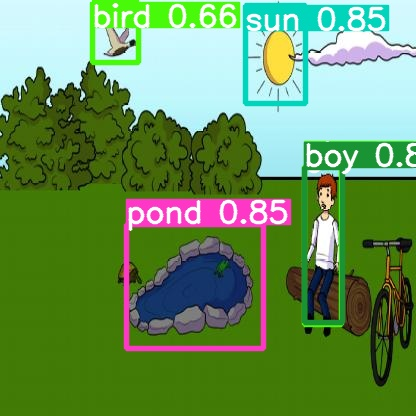

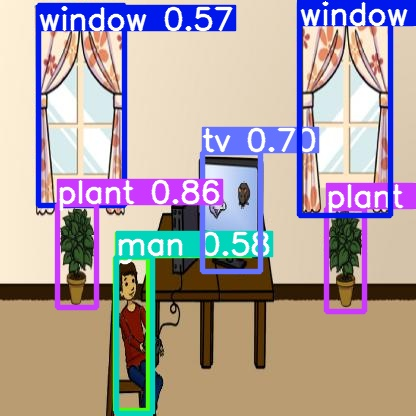

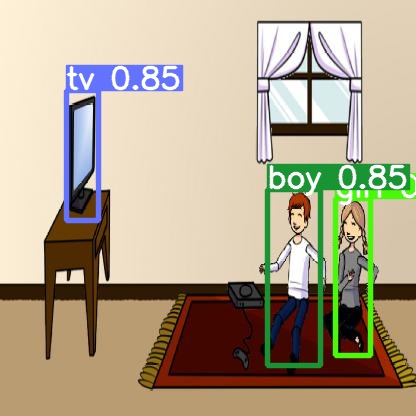

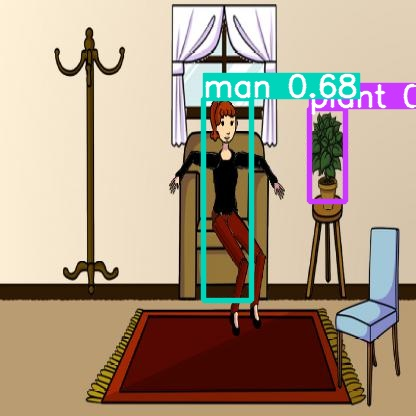

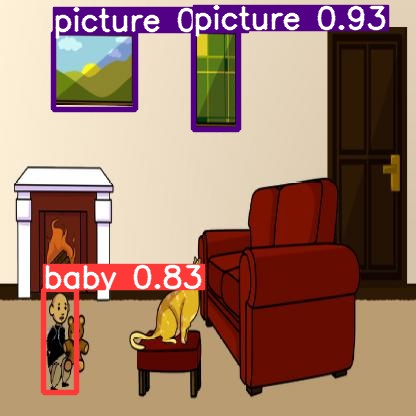

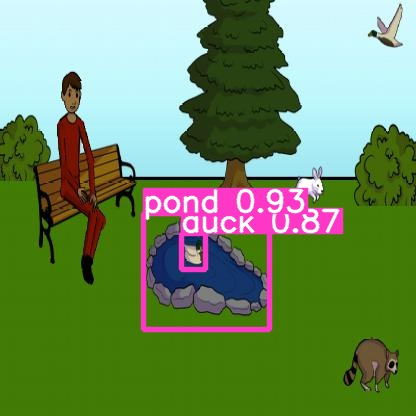

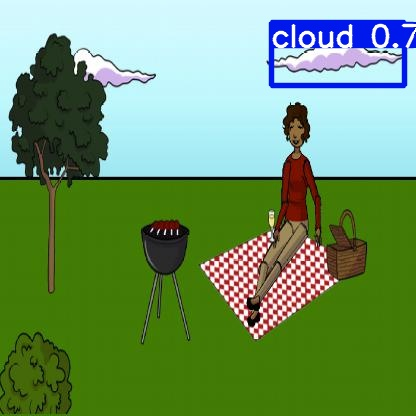

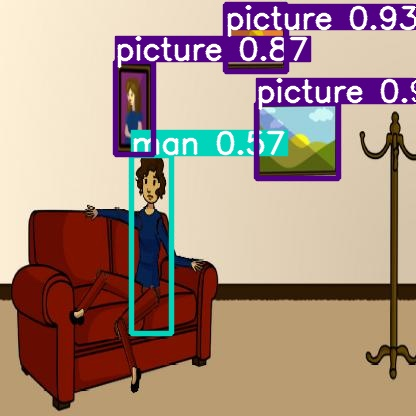

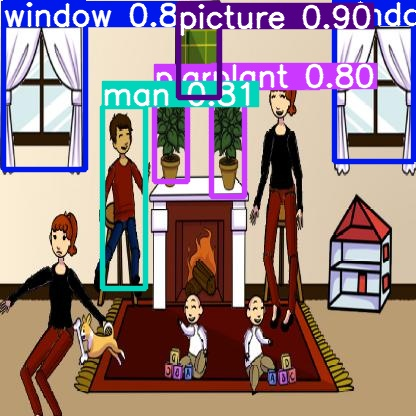

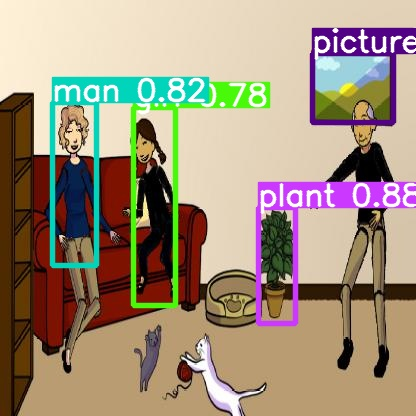

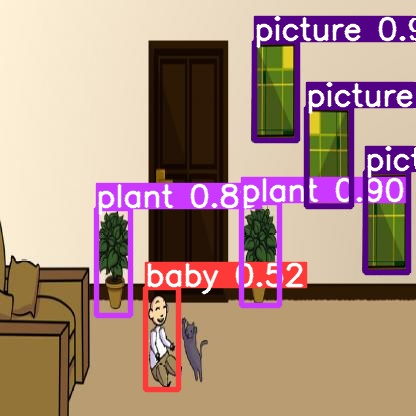

In [ ]:
import glob
from IPython.display import Image, display

for imageName in glob.glob('/content/yolov5/runs/detect/exp/*.jpg'): #assuming JPG
    display(Image(filename=imageName))
    print("\n")